In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [2]:
fraud_data = pd.read_csv('fraudTrain.csv', index_col = 0) # remove unnamed: 0
fraud_data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

Some of variables are in object type, so I apply conversion of type from categorical variables into numerical ones. And visualize using pie chart to clearly see the ratio.

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


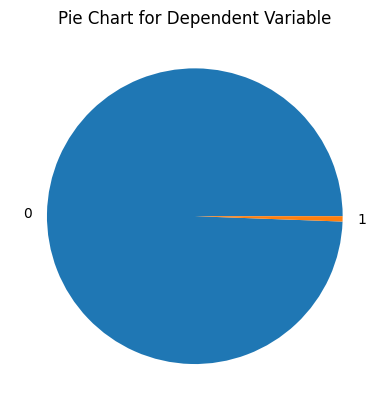

In [4]:
plt.pie(fraud_data['is_fraud'].value_counts(), labels=[0,1])
plt.title('Pie Chart for Dependent Variable')
print(fraud_data['is_fraud'].value_counts())
plt.show()

Based on above findings, we see that the data between nonfraud case and fraud case is highly imbalanced.

So I use a tool known as missingno to provide the number of missing observations.

In [5]:
# install missingno module
#!pip install missingno 


<Axes: >

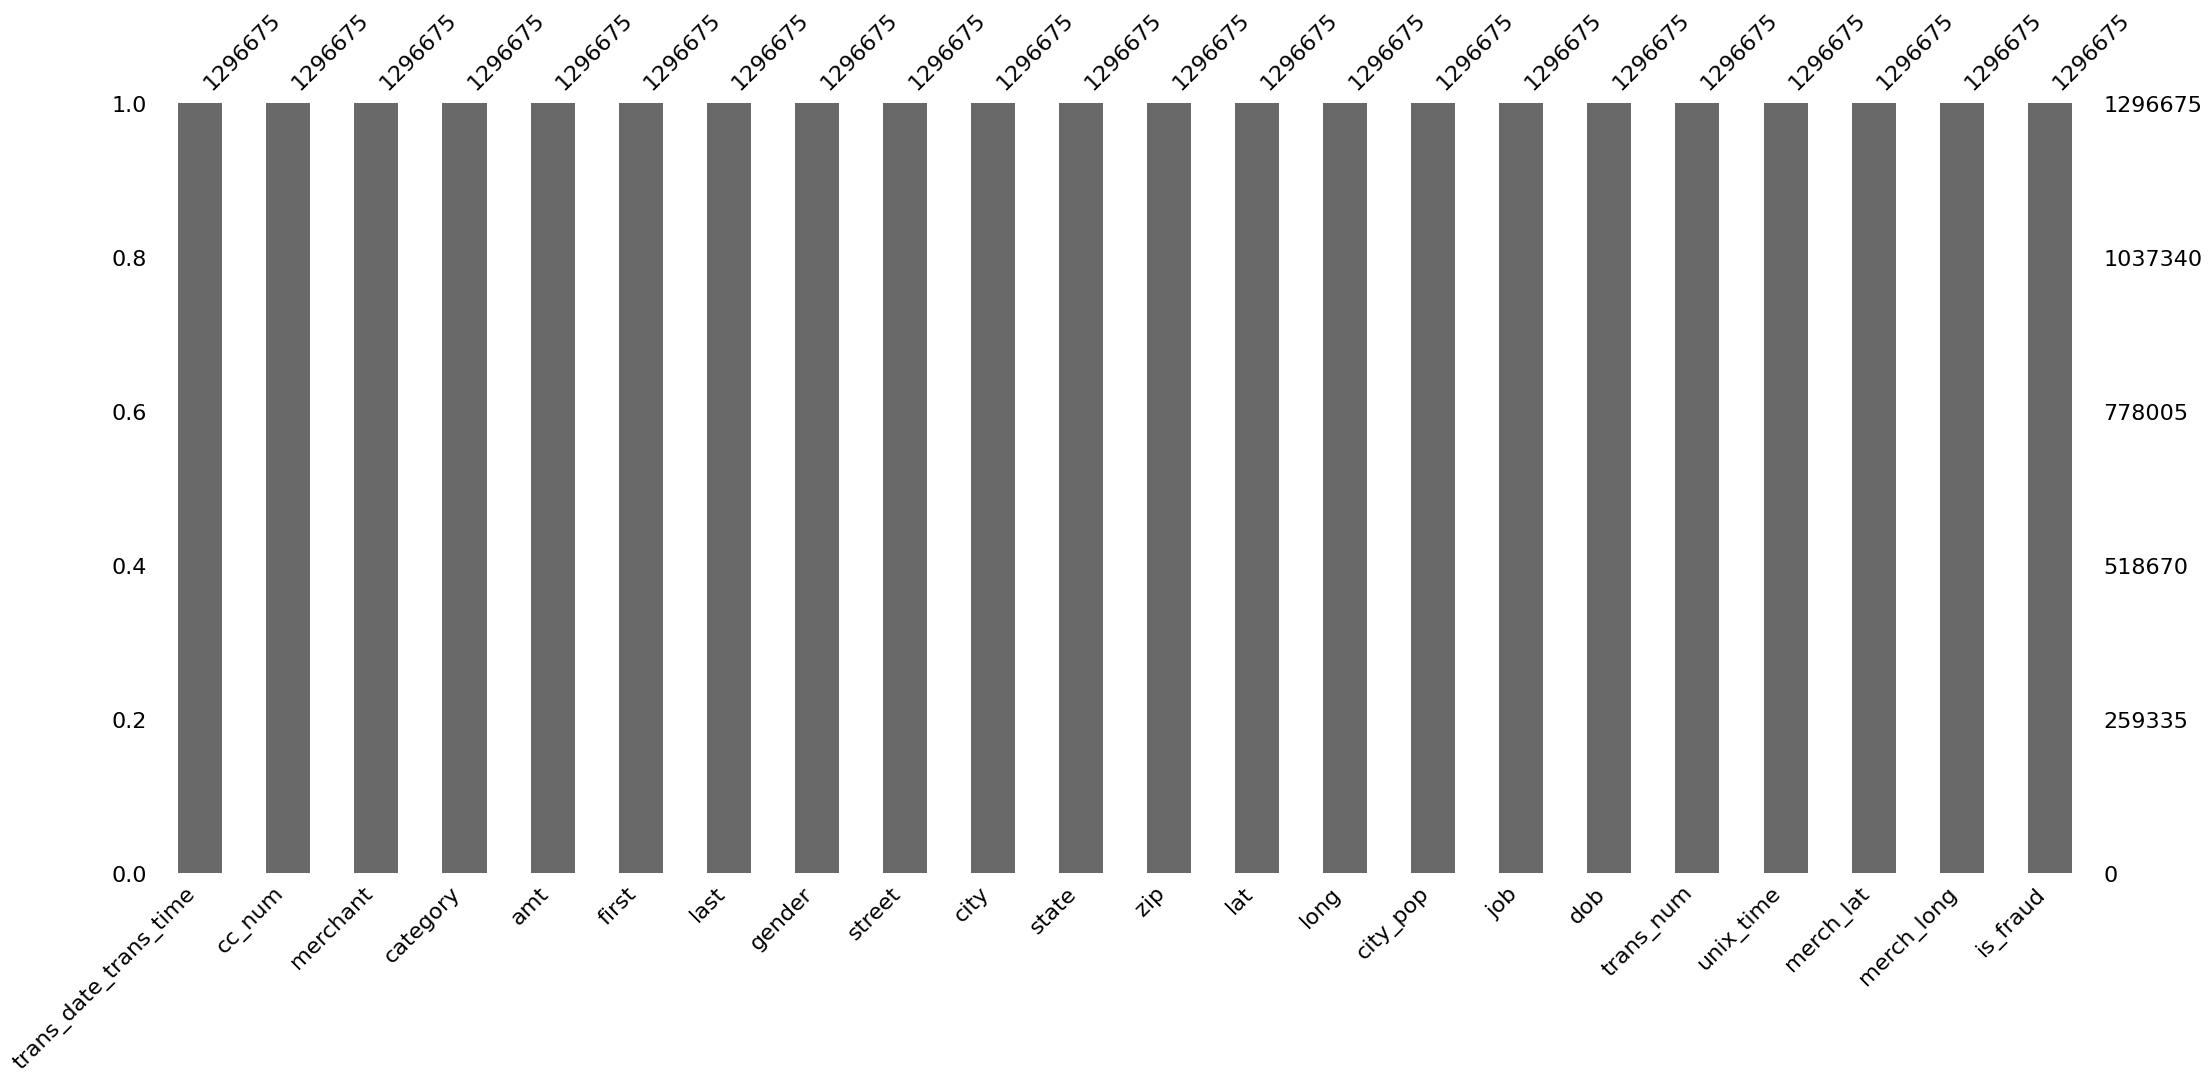

In [6]:
import missingno as msno

msno.bar(fraud_data)

Based on above figure, it indicates the number of nonmissing observations per variable at the top, 
and on the left-hand side we can see the percentage of nonmissing values.

This analysis s shows that the data has no missing values.

Next, change the 'trans_date_trans_time' to proper datetime format and extract the day and hour, so I can examine whether the fraudelent activity increases during specific time so we can see the pattern and trends.

I analyze how fraud varies across different categories using bar plots.

In [7]:
fraud_data['time'] = pd.to_datetime(fraud_data['trans_date_trans_time'])
del fraud_data['trans_date_trans_time']

# extract day and hour
fraud_data['days'] = fraud_data['time'].dt.day_name()
fraud_data['hour'] = fraud_data['time'].dt.hour

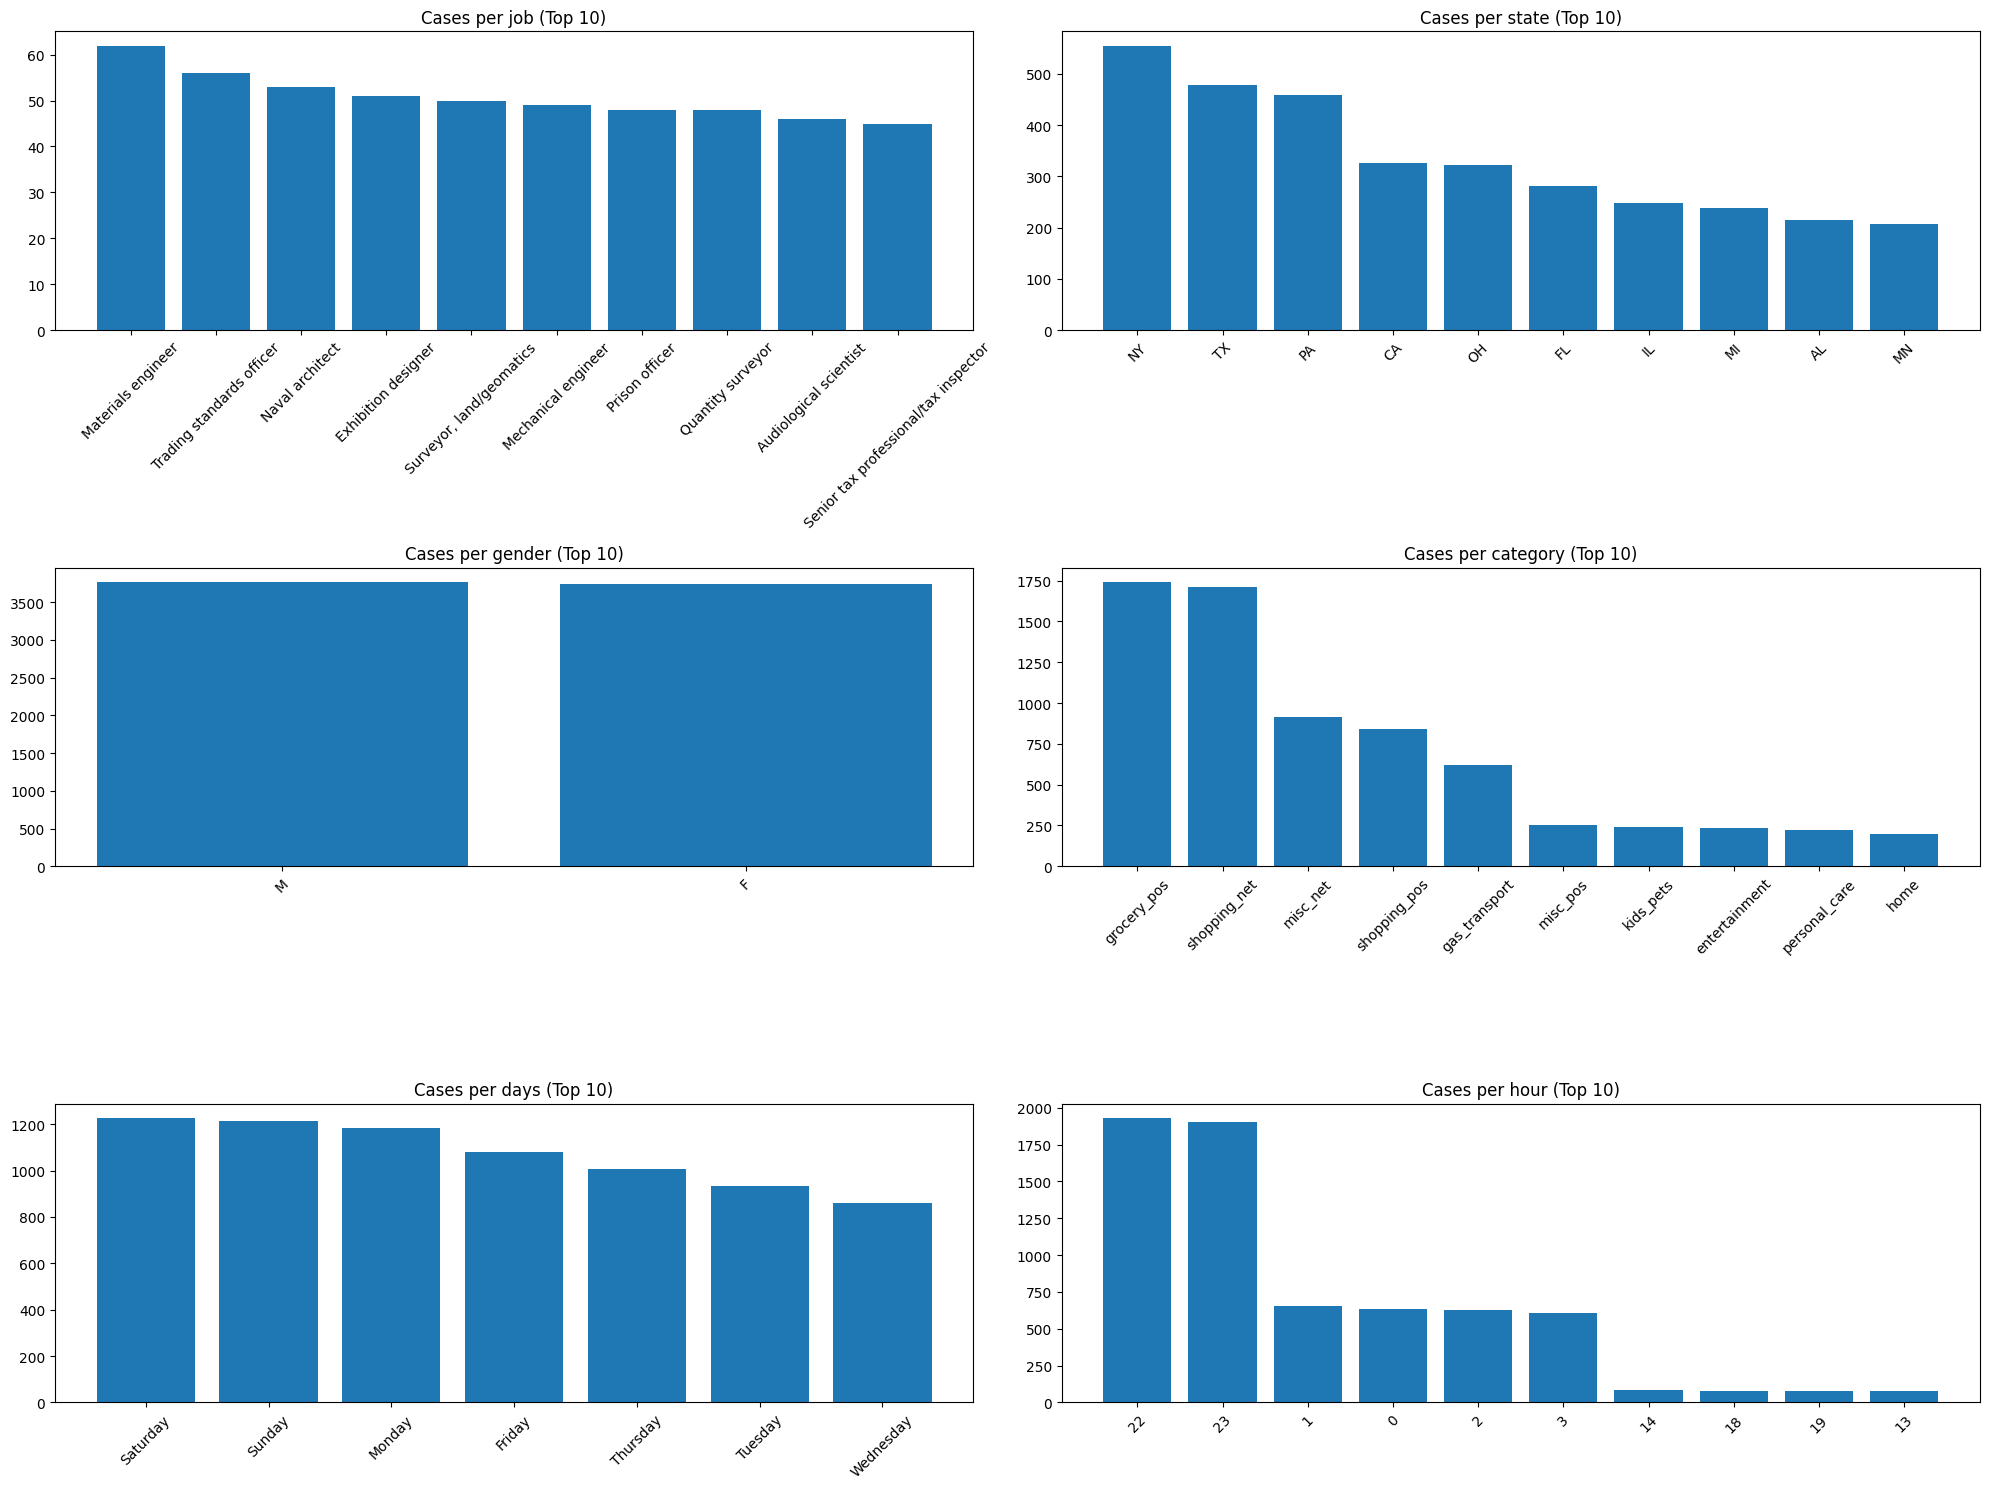

<BarContainer object of 10 artists>

In [8]:
import matplotlib.pyplot as plt
import math

def fraud_cat(cols):
    k = 1
    rows = math.ceil(len(cols) / 2)
    plt.figure(figsize=(20, 5 * rows))

    for col in cols:
        # top 10 categories among fraud cases
        vc = (fraud_data.loc[fraud_data['is_fraud'] == 1, col]
              .value_counts()
              .head(10))

        plt.subplot(rows, 2, k)
        bar_plot = plt.bar(vc.index.astype(str), vc.values)
        plt.title(f"Cases per {col} (Top 10)")
        plt.xticks(rotation=45)
        k += 1

    plt.tight_layout()
    plt.show()
    return vc, bar_plot
cols = ['job', 'state', 'gender', 'category', 'days', 'hour']
_, bar_plot = fraud_cat(cols)
bar_plot

In [9]:
#converts categorical variables into numerical columns using one-hot encoding
cols = ['amt', 'gender', 'state', 'category', 
       'city_pop', 'job', 'is_fraud', 'days', 'hour']

fraud_data_df=fraud_data[cols]
cat_cols = fraud_data[cols].select_dtypes(include='object').columns

def one_hot_encoded_cat(data, cat_cols):
    for i in cat_cols:
        df1 = pd.get_dummies(data[str(i)],
                             prefix=i, drop_first=True)
        data.drop(str(i), axis=1, inplace=True)
        data = pd.concat([data, df1], axis=1)
    return data

fraud_df = one_hot_encoded_cat(fraud_data_df, cat_cols)

Apart from doing categorical variable analysis,  I also check on the numerical variables such as amount, population, and hour. I use the correlation analysis to provide the intereactions among these variables and cisualizing them on heat map

In [10]:
num_col = fraud_data_df.select_dtypes(exclude = 'object').columns
fraud_data_df = fraud_data_df[num_col]
fraud_data_df = fraud_data_df.drop(columns=['is_fraud'])

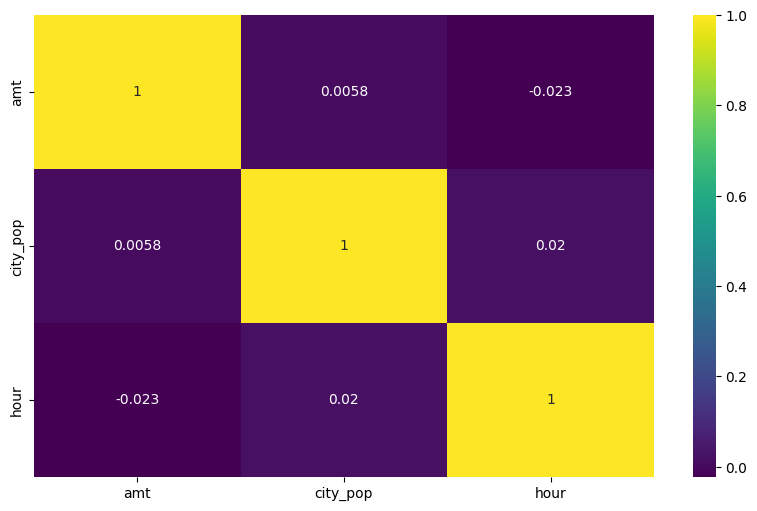

In [11]:
plt.figure(figsize=(10,6))
cormat = fraud_data_df.corr()
top_corr_features = cormat.index
heat_map = sns.heatmap(cormat, annot=True, cmap = "viridis")

**Supervised Learning Modeling for Fraud Examination**

Since the data is imabalance, so I apply **undersampling method**, which match the majority classess to minority classes.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, f1_score)

non_fraud_class = fraud_df[fraud_df['is_fraud'] == 0]
fraud_class = fraud_df[fraud_df['is_fraud'] == 1]

non_fraud_count, fraud_count = fraud_df['is_fraud'].value_counts()
print("The number of observations in non_fraud_class: ", non_fraud_count)
print("The number of observations in fraud_class: ", fraud_count)

The number of observations in non_fraud_class:  1289169
The number of observations in fraud_class:  7506


In [13]:
#sampling fraud
non_fraud_under = non_fraud_class.sample(fraud_count)
#concate data fraudulent cases with no fraudulent cases
under_sampled = pd.concat([non_fraud_under, fraud_class], axis=0)
# creting independent cariables by dropping is_fraud
X_under = under_sampled.drop('is_fraud', axis=1)
#creting dependent variables by is_fraud
y_under = under_sampled

X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(X_under, y_under, random_state=0) 


Undersampling method above allows us to apply models. Thus, I use classification models to describe and observe the performance of these models in detecting fraud

In [16]:
# to be continue